## **IMC Round 5 Algorithmic and Manual Data Analysis**

## Imports

In [5]:
import numpy as np
import pandas as pd
from collections import defaultdict
from ROUND_1_2.code_round_1 import data_pre_processing, eda_functions
# ploting
import matplotlib.pyplot as plt
import seaborn as sns 

## Data

In [4]:
data_l2_book_paths = [
    'ROUND_5/data/prices_round_5_day_2.csv', 
    'ROUND_5/data/prices_round_5_day_3.csv', 
    'ROUND_5/data/prices_round_5_day_4.csv'
]

l2_books = data_pre_processing.data_pre_process_pipeline(data_l2_book_paths)

def product_returns(l2_books: dict[str, list], feature: str = 'mid_returns'):
    """
    complies all assets returns into one dataframe
    """
    asset_returns = {}
    for asset, book in l2_books.items():
        asset_returns[asset] = book.loc[:, feature].reset_index(drop = True)

    return pd.DataFrame(asset_returns)

l2_book_returns = product_returns(l2_books)

## Correlation Matrix

High correlation Pairs:                level_0               level_1         0
0  SNACKPACK_RASPBERRY   SNACKPACK_PISTACHIO -0.830668
1  SNACKPACK_RASPBERRY  SNACKPACK_STRAWBERRY -0.923171
2    SNACKPACK_VANILLA   SNACKPACK_CHOCOLATE -0.915191
3  SNACKPACK_PISTACHIO  SNACKPACK_STRAWBERRY  0.912558


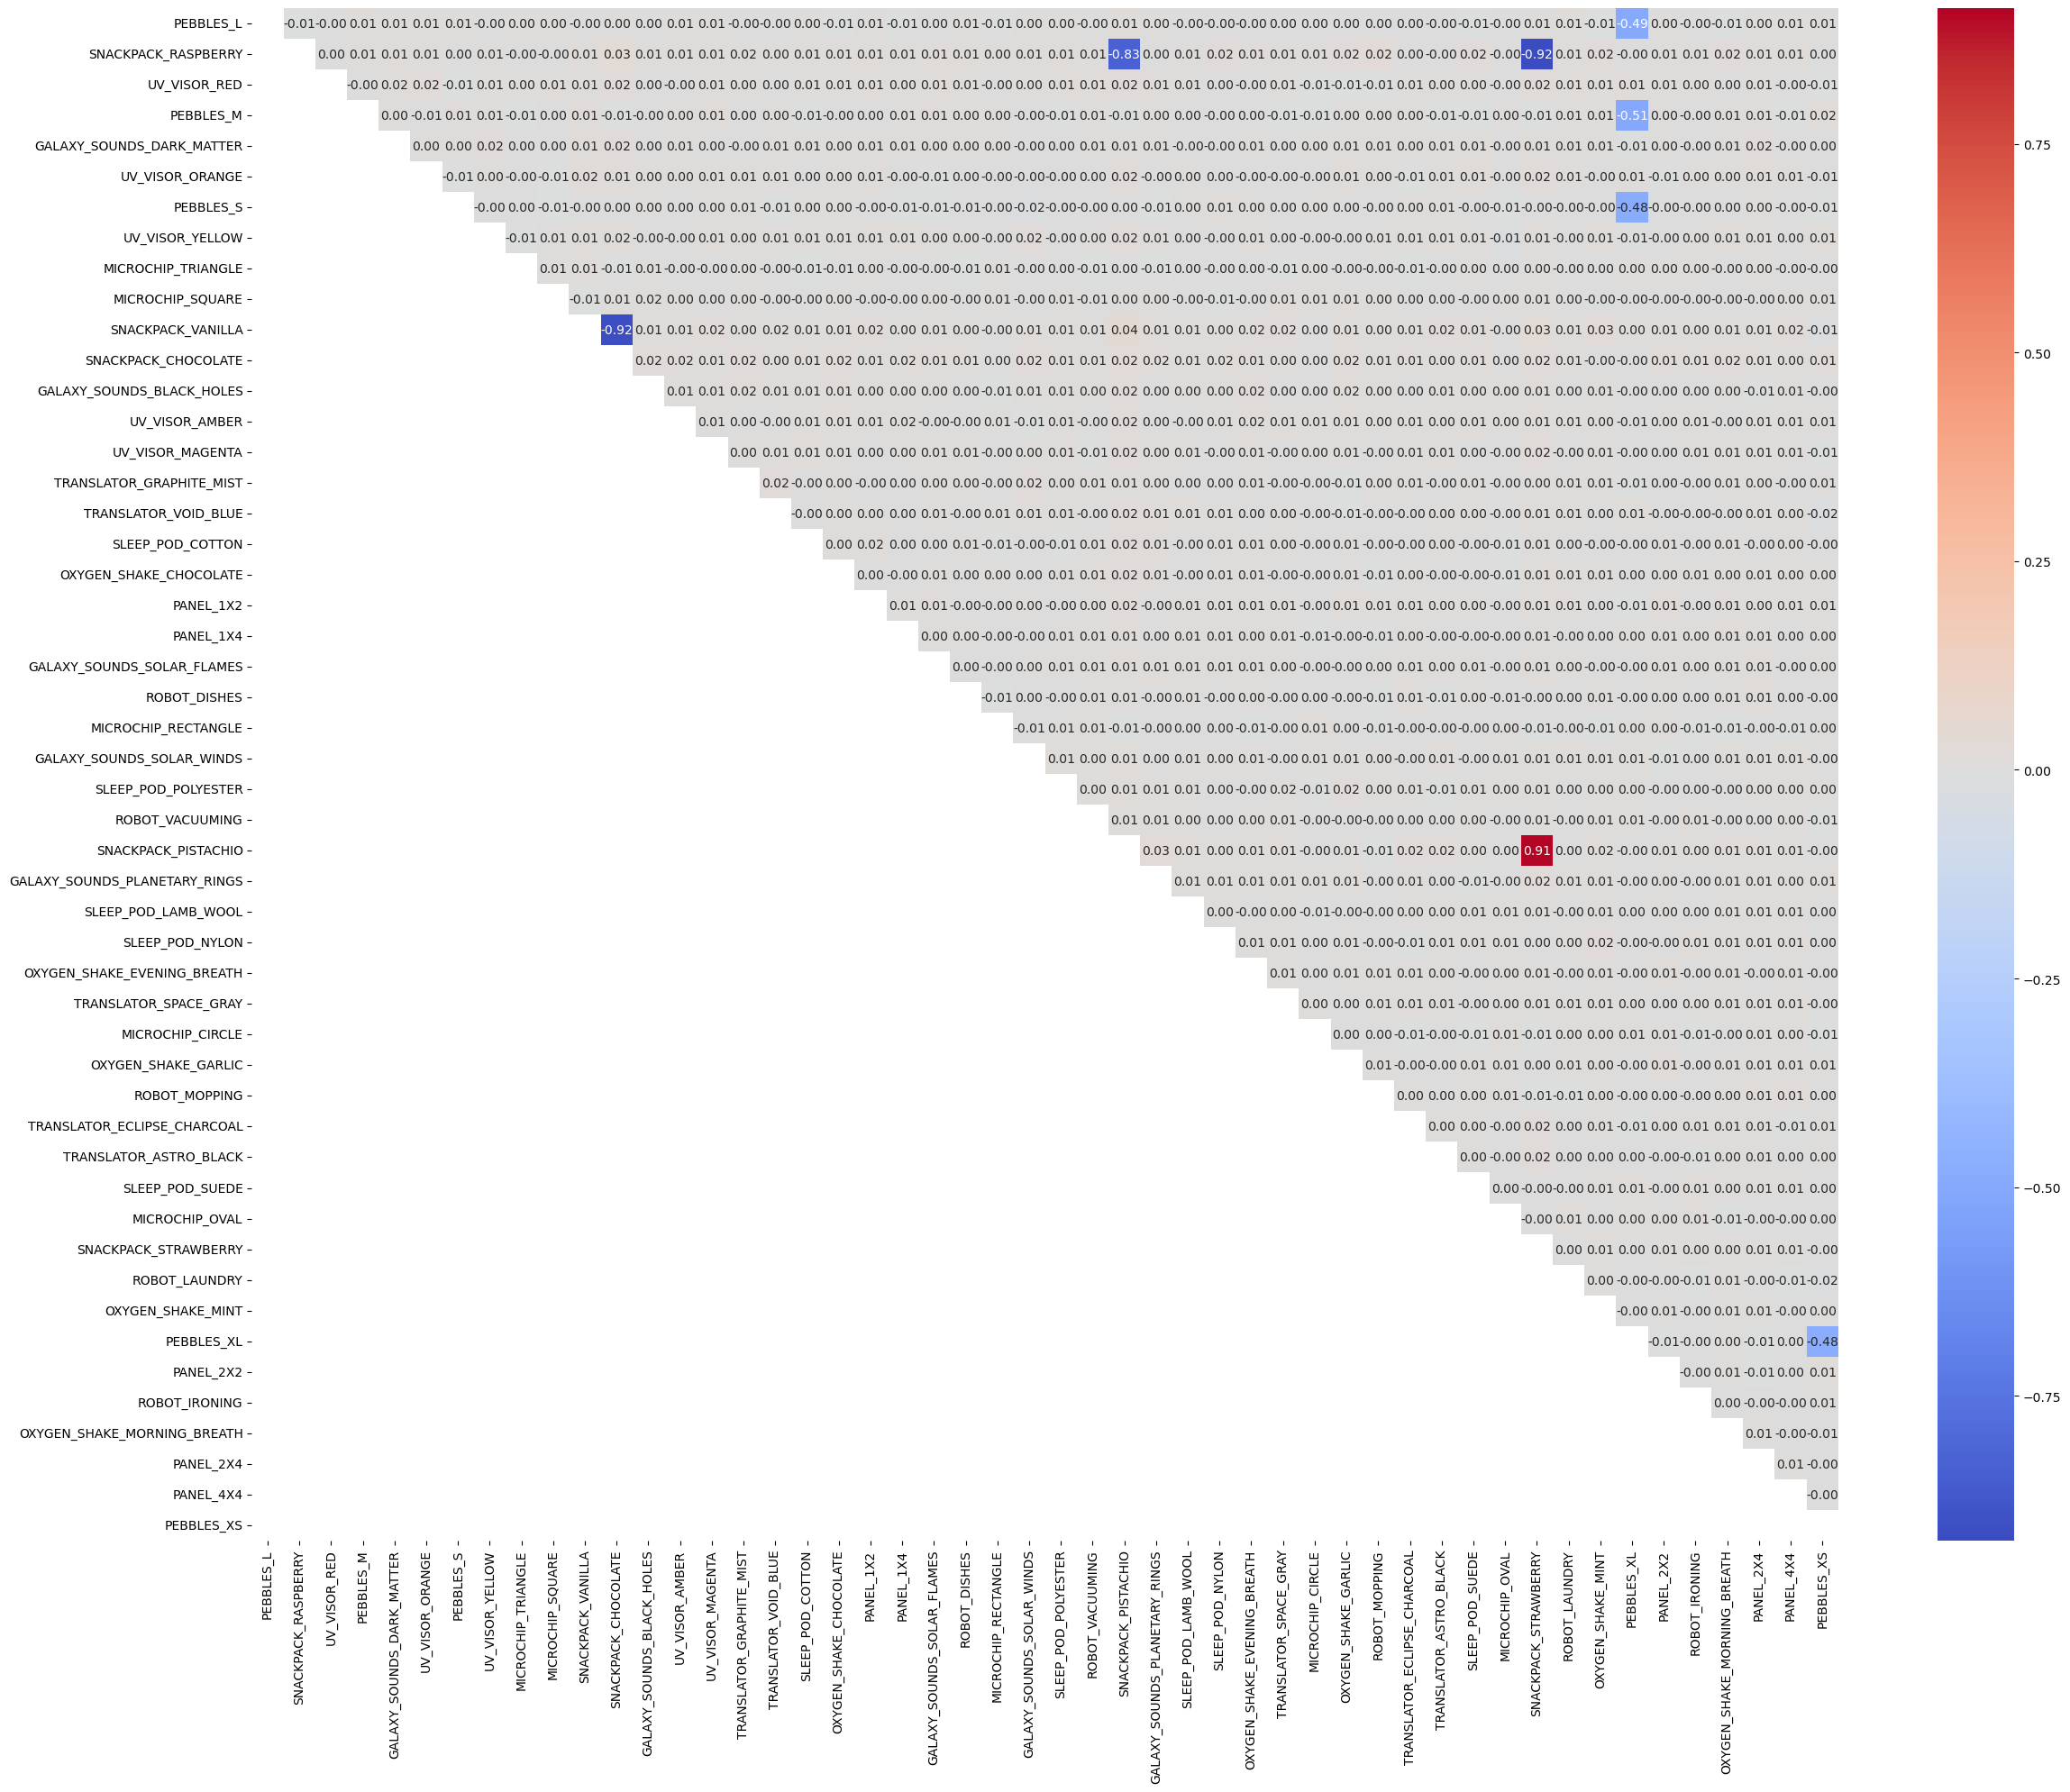

In [ ]:
# filter for high signal correlations 
signal_corr = 0.8
corr = l2_book_returns.corr()
corr_triu = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
high_corr_pairs = (
    corr_triu.stack().loc[lambda x: abs(x) > 0.7].reset_index()
)
print('High correlation Pairs:', high_corr_pairs)

# plot
assets = l2_books.columns
plt.figure(figsize=(25, 20))
sns.heatmap(corr_triu, cmap = 'coolwarm', annot = True, fmt = '.2f', xticklabels = assets, yticklabels = assets)
plt.tight_layout();

## Cointegration

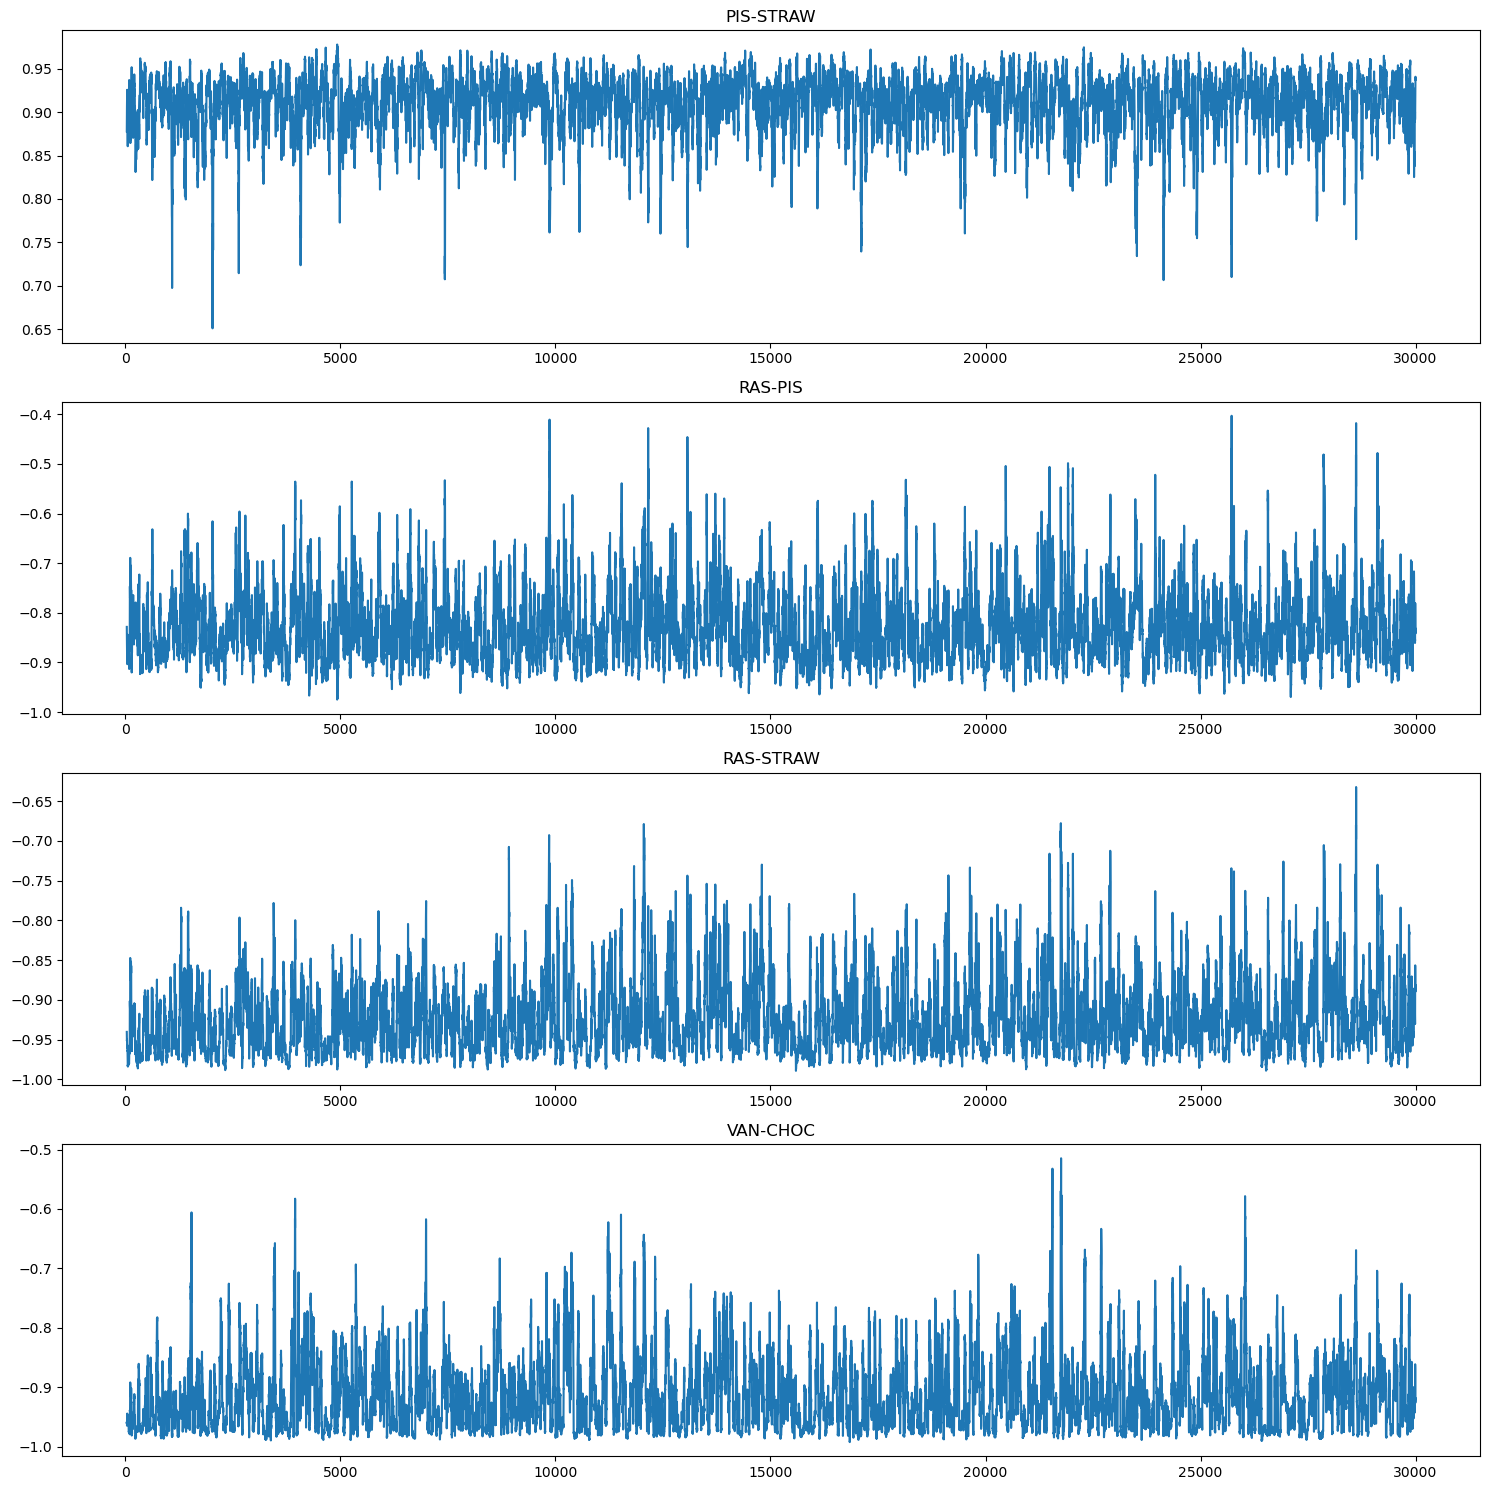

In [ ]:
pair_data = {}
pair_corrs = {} # long run moving average of correlation 
for row in high_corr_pairs.drop(labels = 0, axis = 1).itertuples():
    x1, x2 = row.level_0, row.level_1
    
    pair = x1+'-'+x2
    
    dat1, dat2 = l2_books[x1], l2_books[x2]
    pair_data[pair] = {
        x1: dat1, 
        x2: dat2
    }

    x1_feature, x2_feature = dat1.loc[:, 'mid_returns'].reset_index(drop=True), dat2.loc[:, 'mid_returns'].reset_index(drop=True)
    dat = pd.concat([x1_feature, x2_feature], axis = 1)
    one_day = 1e4
    freq = int(one_day*5/(24*60)) # rolling 5 minute correlation
    pair_corrs[pair] = (
        x1_feature.rolling(freq).corr(x2_feature)
    )

# plot
fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (15, 15))
ax[0].set_title('PIS-STRAW')
ax[0].plot(pair_corrs['SNACKPACK_PISTACHIO-SNACKPACK_STRAWBERRY'])

ax[1].set_title('RAS-PIS')
ax[1].plot(pair_corrs['SNACKPACK_RASPBERRY-SNACKPACK_PISTACHIO'])

ax[2].set_title('RAS-STRAW')
ax[2].plot(pair_corrs['SNACKPACK_RASPBERRY-SNACKPACK_STRAWBERRY'])

ax[3].set_title('VAN-CHOC')
ax[3].plot(pair_corrs['SNACKPACK_VANILLA-SNACKPACK_CHOCOLATE'])
plt.tight_layout();